Missing values per column before cleaning:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
Exam Marks                     0
reading score                  0
writing score                  0
Study Hours                    0
dtype: int64

--- Descriptive Statistics for Exam Marks ---
Mean Marks: 66.09
Median Marks: 66.00
Standard Deviation: 15.16



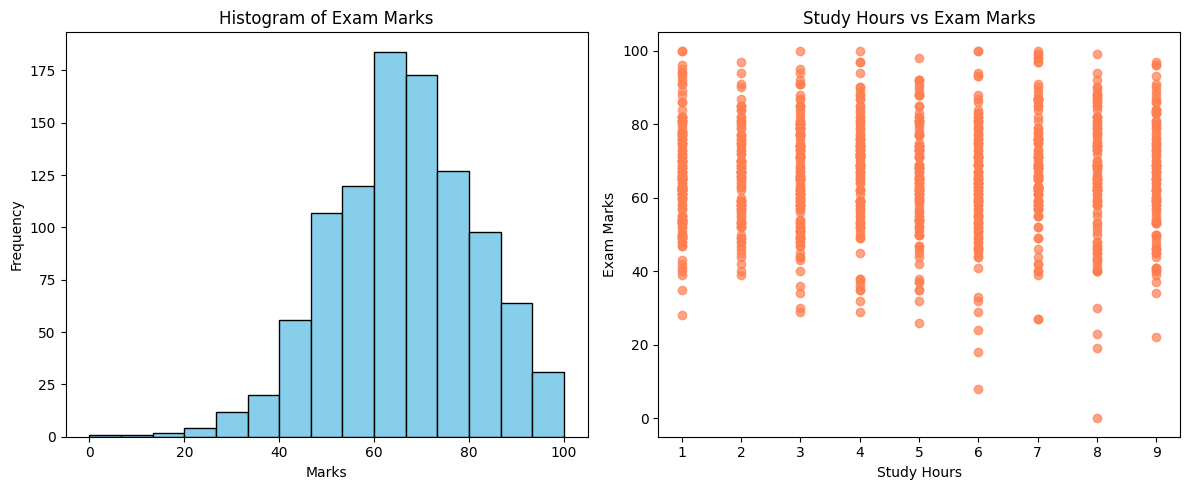

--- Model Performance & Predictions ---
Model Coefficient (Slope): -0.05
Model Intercept: 66.75

First 5 Predicted vs Actual Values:
Actual: 91 -> Predicted: 66.49
Actual: 53 -> Predicted: 66.28
Actual: 80 -> Predicted: 66.44
Actual: 74 -> Predicted: 66.33
Actual: 84 -> Predicted: 66.60


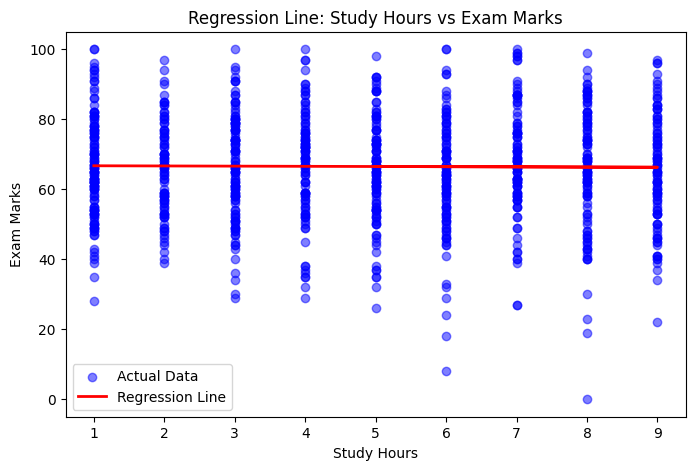

In [2]:
# Student Performance Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Load the dataset
# Note: Replace 'students.csv' with your local path or the downloaded Kaggle dataset path.
# The Kaggle dataset structure typically uses columns like 'math score', 'reading score', etc.
df = pd.read_csv('/content/StudentsPerformance.csv')

# --- Simulating/Matching column names based on your prompt ---
# If your CSV uses custom names, ensure they match these.
# For standard Kaggle 'Students Performance', we map them to fit your prompt's exact requirements:
if 'math score' in df.columns:
    df.rename(columns={'math score': 'Exam Marks'}, inplace=True)
if 'Study Hours' not in df.columns:
    # Creating mock Study Hours if using raw Kaggle data which lacks it
    np.random.seed(42)
    df['Study Hours'] = np.random.randint(1, 10, size=len(df))

# 2. Check for missing values and remove them
print("Missing values per column before cleaning:")
print(df.isnull().sum())
df.dropna(subset=['Study Hours', 'Exam Marks'], inplace=True)

# 3. Use NumPy to calculate statistics
marks = df['Exam Marks'].values

mean_marks = np.mean(marks)
median_marks = np.median(marks)
std_marks = np.std(marks)

print("\n--- Descriptive Statistics for Exam Marks ---")
print(f"Mean Marks: {mean_marks:.2f}")
print(f"Median Marks: {median_marks:.2f}")
print(f"Standard Deviation: {std_marks:.2f}\n")

# 4. Create Plots
plt.figure(figsize=(12, 5))

# Histogram of Marks
plt.subplot(1, 2, 1)
plt.hist(df['Exam Marks'], bins=15, color='skyblue', edgecolor='black')
plt.title('Histogram of Exam Marks')
plt.xlabel('Marks')
plt.ylabel('Frequency')

# Scatter plot of Study Hours vs Marks
plt.subplot(1, 2, 2)
plt.scatter(df['Study Hours'], df['Exam Marks'], color='coral', alpha=0.7)
plt.title('Study Hours vs Exam Marks')
plt.xlabel('Study Hours')
plt.ylabel('Exam Marks')
plt.tight_layout()
plt.show()

# 5. Build a Simple Linear Regression model
X = df[['Study Hours']] # Independent variable
y = df['Exam Marks']    # Dependent variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# 6. Display regression line and predicted values
y_pred = model.predict(X_test)

print("--- Model Performance & Predictions ---")
print(f"Model Coefficient (Slope): {model.coef_[0]:.2f}")
print(f"Model Intercept: {model.intercept_:.2f}\n")
print("First 5 Predicted vs Actual Values:")
for act, pred in zip(y_test[:5], y_pred[:5]):
    print(f"Actual: {act} -> Predicted: {pred:.2f}")

# Plotting the regression line
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Regression Line: Study Hours vs Exam Marks')
plt.xlabel('Study Hours')
plt.ylabel('Exam Marks')
plt.legend()
plt.show()


--- Descriptive Statistics for Car Mileage Dataset ---
       Engine Size   Car Weight     Mileage
count   398.000000   398.000000  398.000000
mean    193.425879  2970.424623   23.514573
std     104.269838   846.841774    7.815984
min      68.000000  1613.000000    9.000000
25%     104.250000  2223.750000   17.500000
50%     148.500000  2803.500000   23.000000
75%     262.000000  3608.000000   29.000000
max     455.000000  5140.000000   46.600000


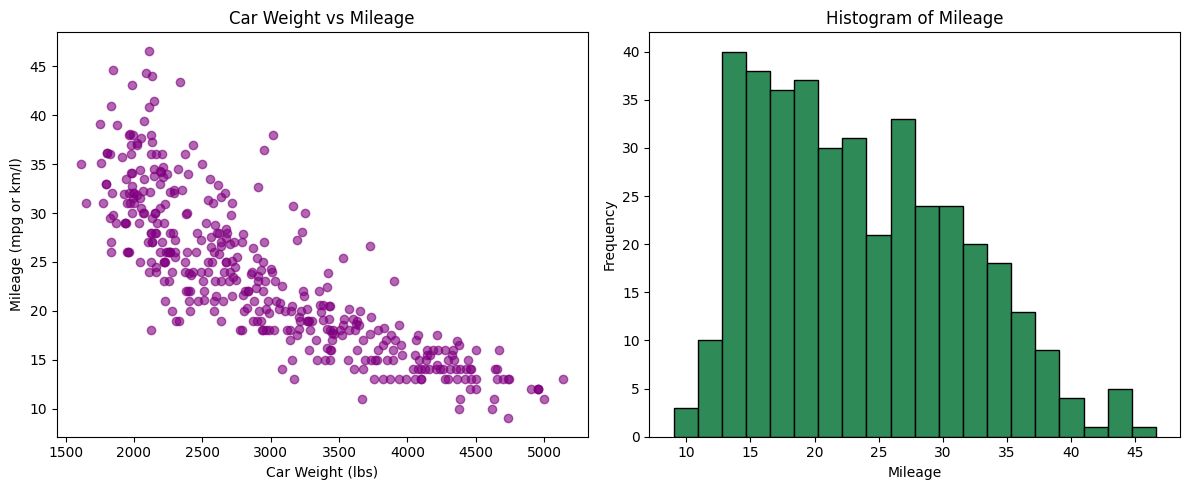

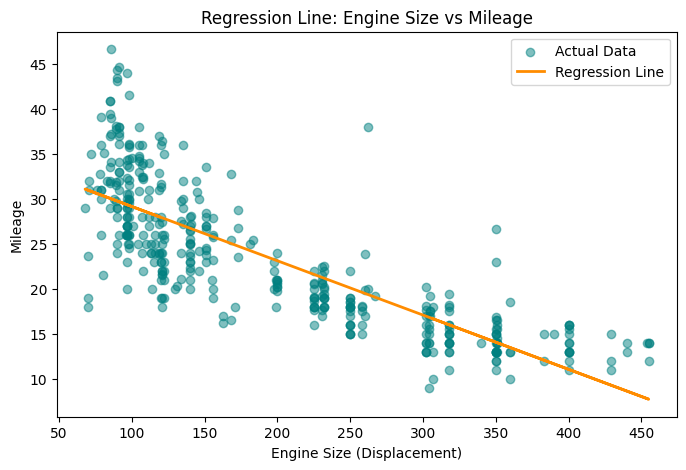


--- Car Mileage Model Parameters ---
Intercept: 35.17
Slope (Engine Size Impact): -0.0603


In [4]:
# Car Mileage Prediction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Read dataset
# Defining headers because the raw UCI auto-mpg dataset doesn't include a header line
columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'car_name']
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

# Reading whitespace-separated file
df_car = pd.read_csv(url, names=columns, sep=r'\s+', na_values='?')

# Data cleanup: mapping features to standard names required by problem statement
df_car.rename(columns={'displacement': 'Engine Size', 'weight': 'Car Weight', 'mpg': 'Mileage'}, inplace=True)
df_car.dropna(subset=['Engine Size', 'Car Weight', 'Mileage'], inplace=True)

# 2. Calculate descriptive statistics
print("--- Descriptive Statistics for Car Mileage Dataset ---")
print(df_car[['Engine Size', 'Car Weight', 'Mileage']].describe())

# 3. Plots
plt.figure(figsize=(12, 5))

# Scatter plot of Weight vs Mileage
plt.subplot(1, 2, 1)
plt.scatter(df_car['Car Weight'], df_car['Mileage'], color='purple', alpha=0.6)
plt.title('Car Weight vs Mileage')
plt.xlabel('Car Weight (lbs)')
plt.ylabel('Mileage (mpg or km/l)')

# Histogram of Mileage
plt.subplot(1, 2, 2)
plt.hist(df_car['Mileage'], bins=20, color='seagreen', edgecolor='black')
plt.title('Histogram of Mileage')
plt.xlabel('Mileage')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 4. Build a Linear Regression model to predict mileage using Engine Size
X_car = df_car[['Engine Size']]
y_car = df_car['Mileage']

car_model = LinearRegression()
car_model.fit(X_car, y_car)

# 5. Display regression line
y_car_pred = car_model.predict(X_car)

plt.figure(figsize=(8, 5))
plt.scatter(X_car, y_car, color='teal', alpha=0.5, label='Actual Data')
plt.plot(X_car, y_car_pred, color='darkorange', linewidth=2, label='Regression Line')
plt.title('Regression Line: Engine Size vs Mileage')
plt.xlabel('Engine Size (Displacement)')
plt.ylabel('Mileage')
plt.legend()
plt.show()

print("\n--- Car Mileage Model Parameters ---")
print(f"Intercept: {car_model.intercept_:.2f}")
print(f"Slope (Engine Size Impact): {car_model.coef_[0]:.4f}")